# Metrics Visualization

This notebook visualizes the evaluation metrics collected from different recommendation models.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set plot style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

In [2]:
def parse_metrics(file_path):
    if not os.path.exists(file_path):
        print(f"File not found: {file_path}")
        return pd.DataFrame()

    with open(file_path, 'r') as f:
        lines = f.readlines()
    
    data = []
    current_model = None
    
    for line in lines:
        line = line.strip()
        if not line:
            continue
        
        if line.startswith("Model:"):
            current_model = line.split("Model:")[1].strip()
        elif ":" in line and current_model:
            if "----" in line:
                continue
                
            parts = line.split(":")
            if len(parts) >= 2:
                metric_raw = parts[0].strip()
                try:
                    value = float(parts[1].strip())
                except ValueError:
                    continue
                
                k = None
                metric_base = metric_raw
                
                if "@" in metric_raw:
                    metric_base, k_str = metric_raw.split("@")
                    k = int(k_str)
                
                data.append({
                    "Model": current_model,
                    "Metric": metric_base,
                    "K": k,
                    "Value": value,
                    "FullMetric": metric_raw
                })
                
    return pd.DataFrame(data)

# Path relative to the notebook location
file_path = '../docs/Milestone 4/metrics_simple_format.txt'
df = parse_metrics(file_path)
df.head()

,Model,Metric,K,Value,FullMetric
0,LightGCN,Precision,20.0,0.0030,Precision@20
1,LightGCN,Precision,50.0,0.0026,Precision@50
2,LightGCN,Precision,100.0,0.0022,Precision@100
3,LightGCN,Precision,1000.0,0.0007,Precision@1000
4,LightGCN,HitRate,20.0,0.0595,HitRate@20


## 1. Ranking Metrics (@K)
Metrics: Precision, HitRate, NDCG, MAP

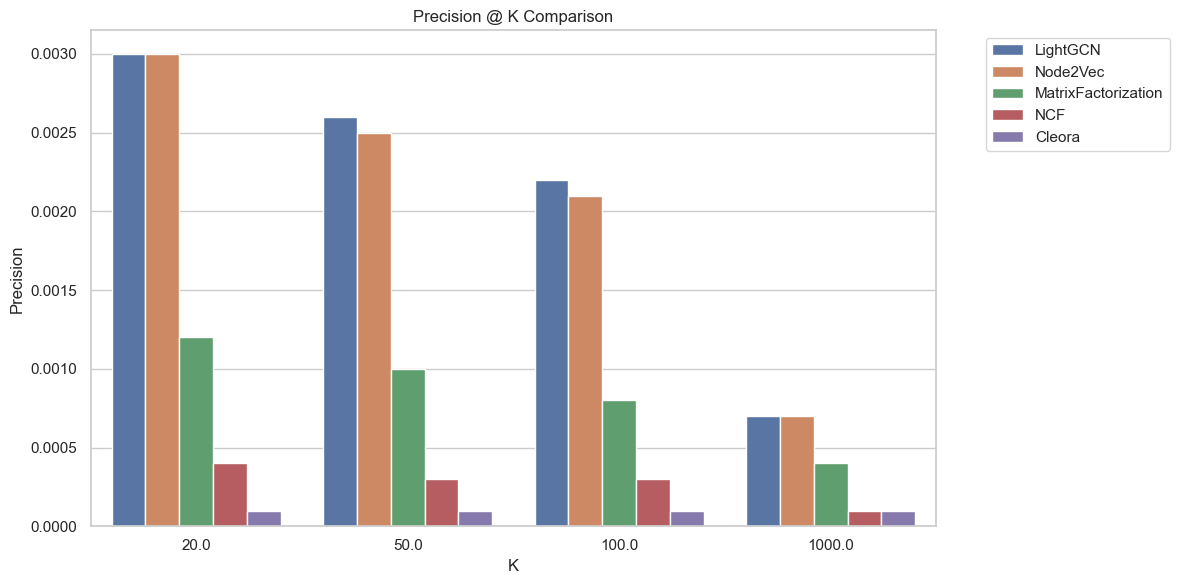

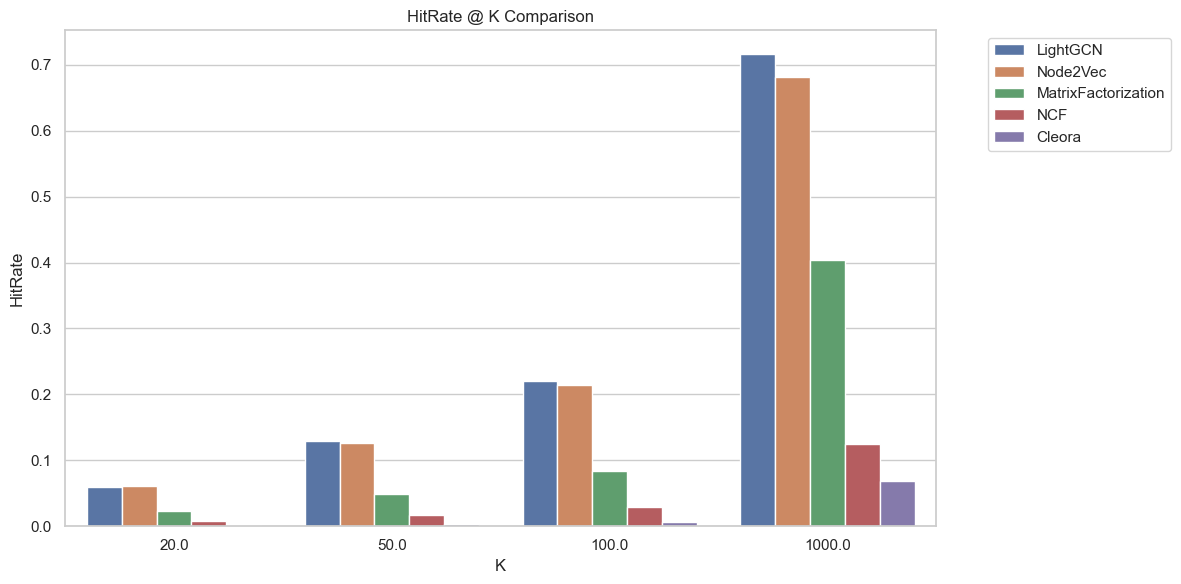

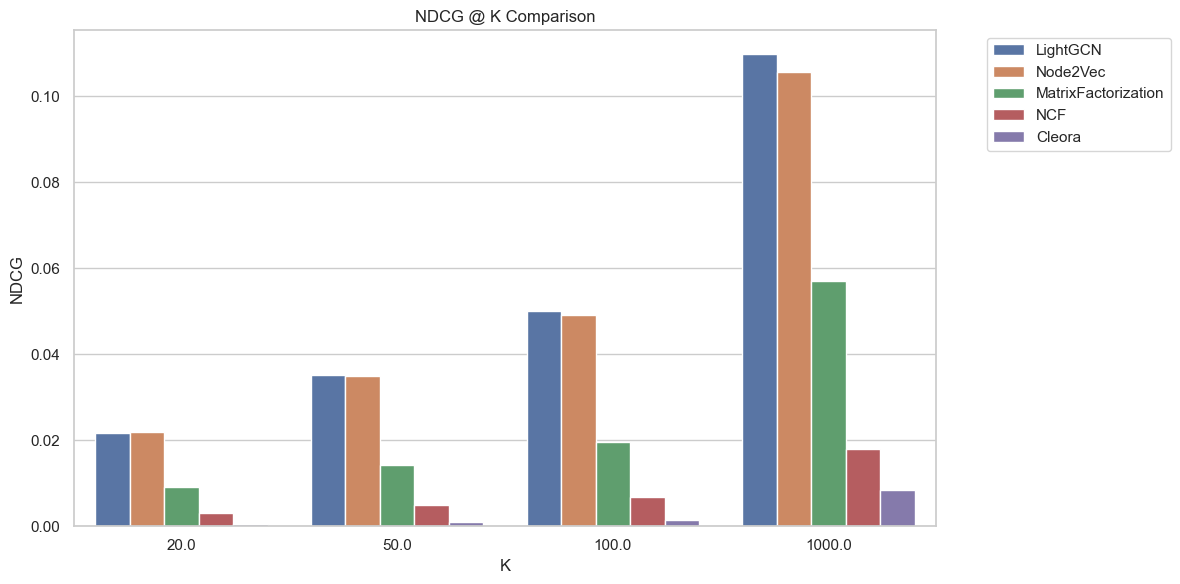

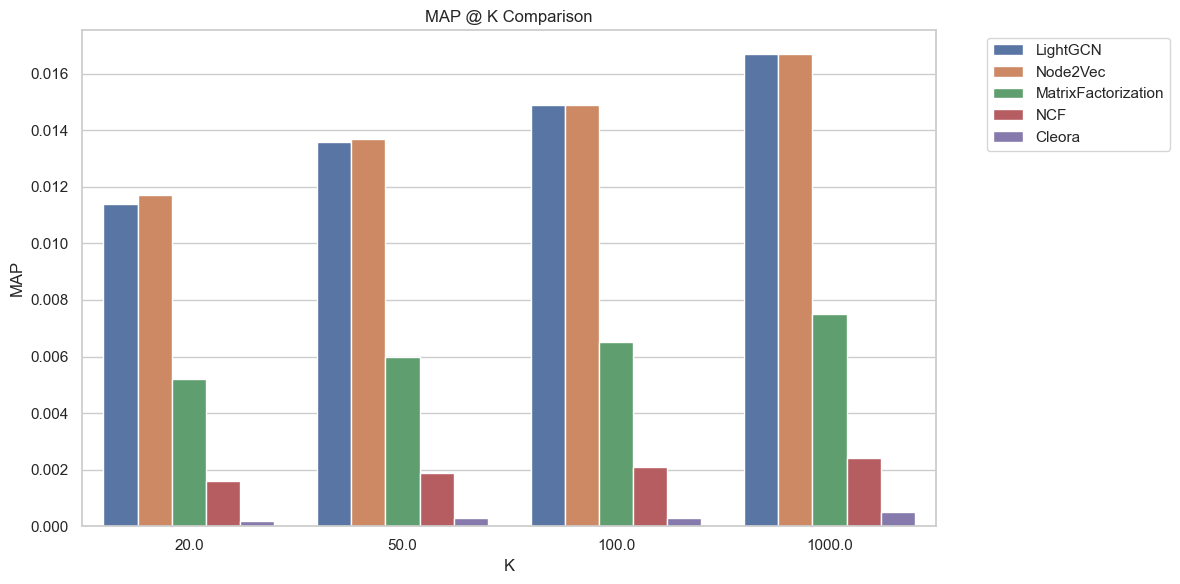

In [3]:
ranking_metrics = ['Precision', 'HitRate', 'NDCG', 'MAP']

for metric in ranking_metrics:
    subset = df[df['Metric'] == metric]
    if subset.empty:
        continue
        
    plt.figure(figsize=(12, 6))
    sns.barplot(data=subset, x='K', y='Value', hue='Model')
    plt.title(f'{metric} @ K Comparison')
    plt.ylabel(metric)
    plt.xlabel('K')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

## 2. Diversity & Novelty Metrics (@K)
Metrics: Diversity, Novelty, Serendipity, AveragePopularity

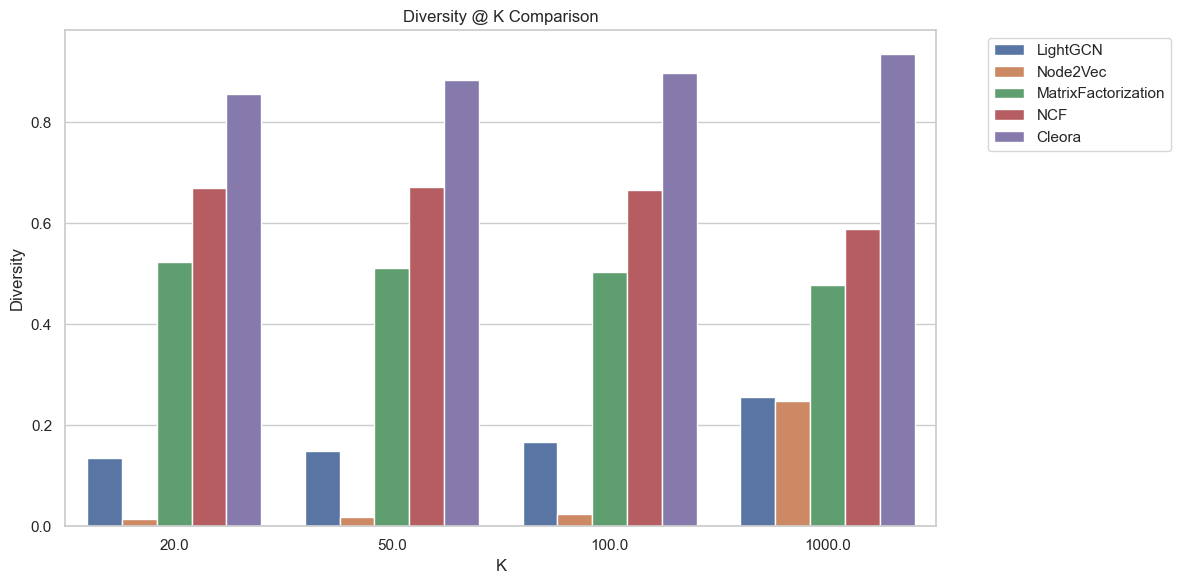

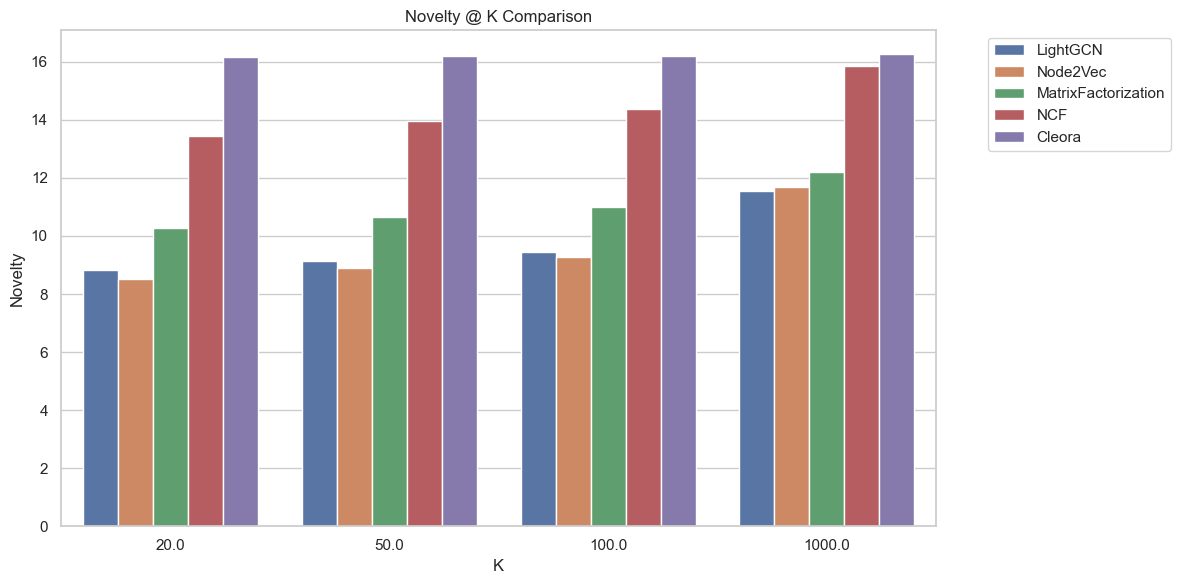

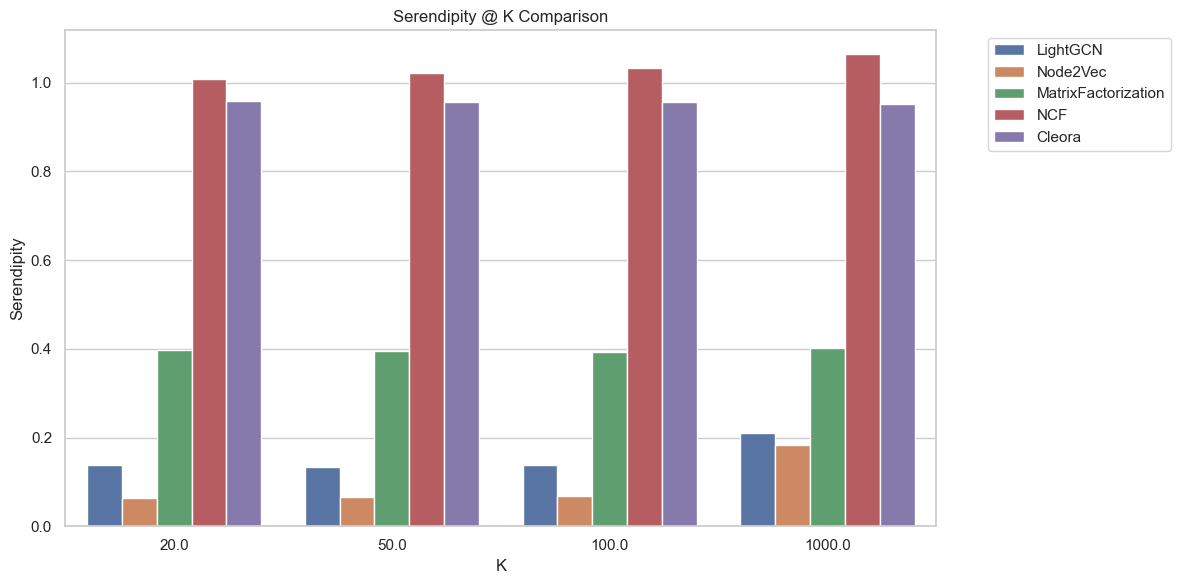

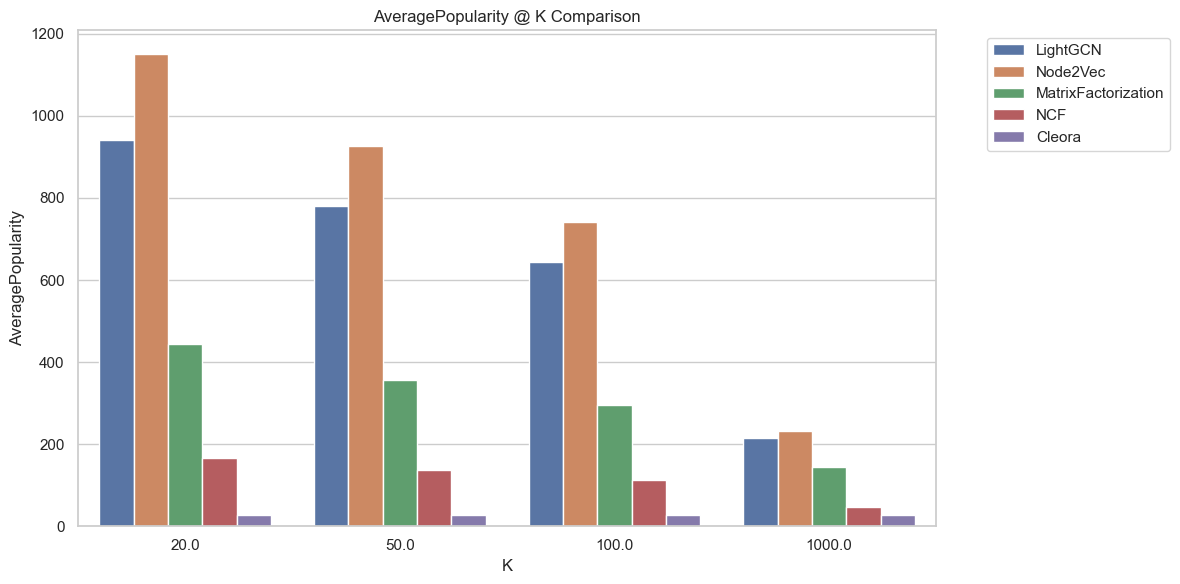

In [4]:
div_metrics = ['Diversity', 'Novelty', 'Serendipity', 'AveragePopularity']

for metric in div_metrics:
    subset = df[df['Metric'] == metric]
    if subset.empty:
        continue
        
    plt.figure(figsize=(12, 6))
    sns.barplot(data=subset, x='K', y='Value', hue='Model')
    plt.title(f'{metric} @ K Comparison')
    plt.ylabel(metric)
    plt.xlabel('K')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

## 3. Global Metrics (Non-@K)
Metrics: AUC, MeanRank, MRR

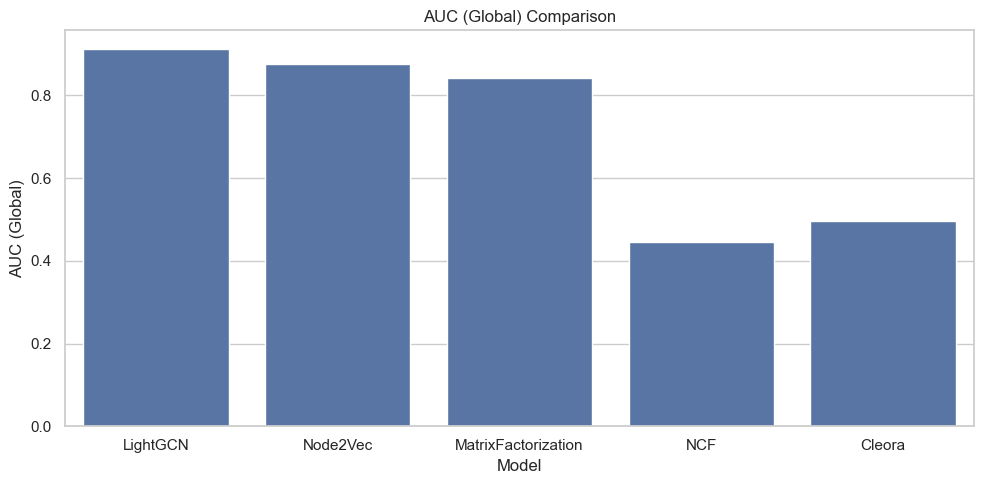

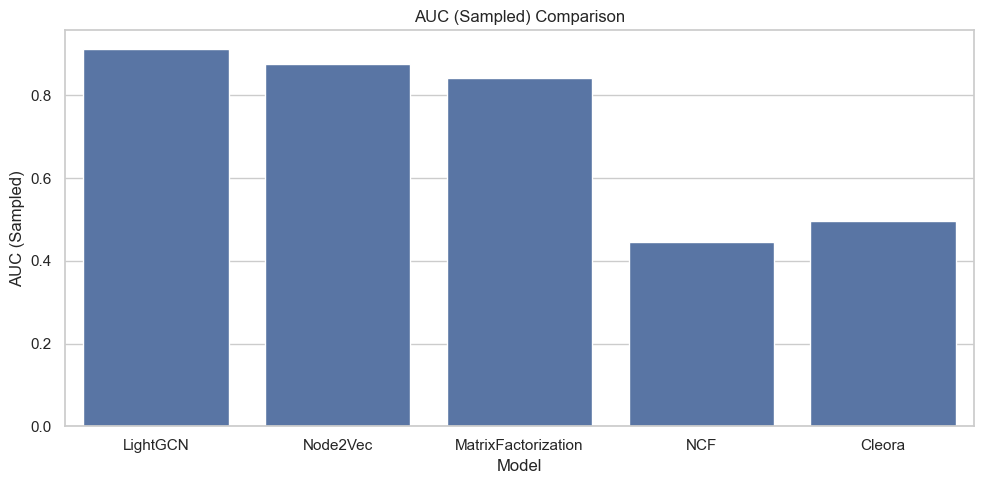

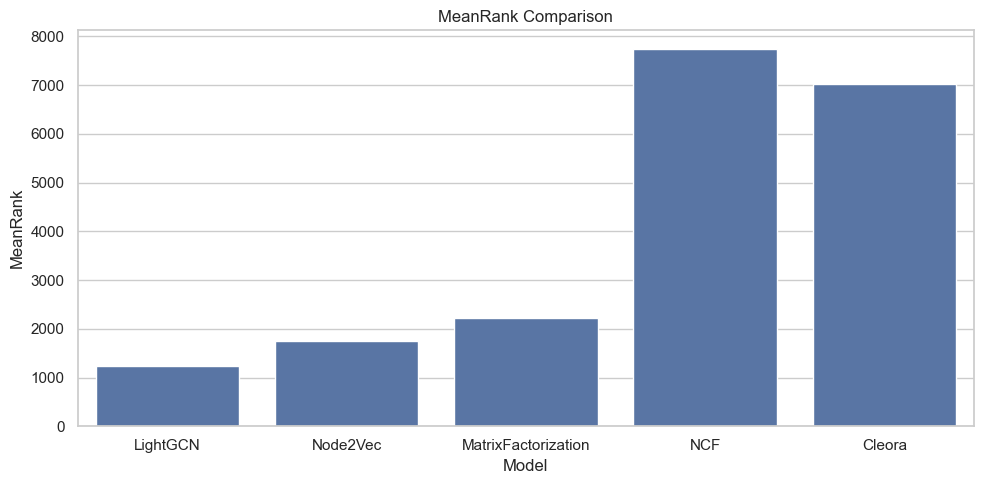

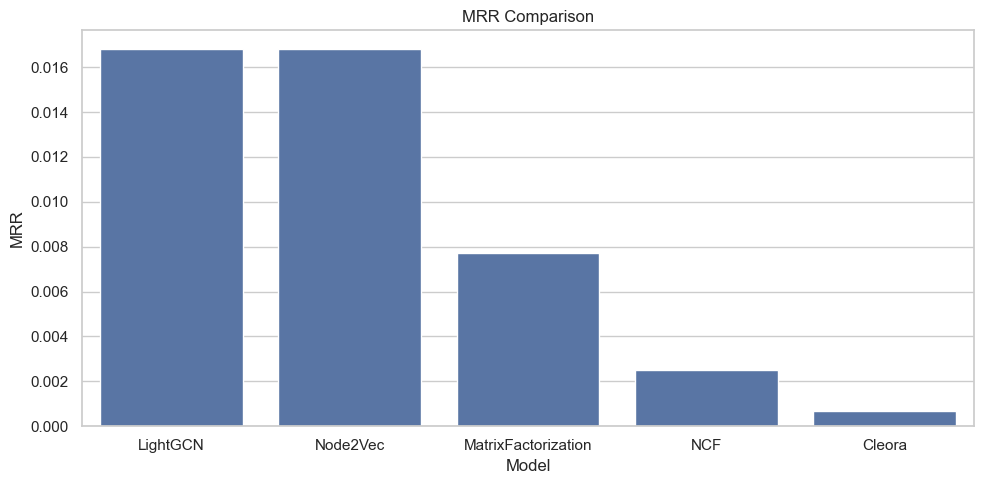

In [5]:
# Filter for metrics that don't have K (K is NaN/None)
global_metrics = df[df['K'].isna()]

if not global_metrics.empty:
    unique_metrics = global_metrics['Metric'].unique()
    
    for metric in unique_metrics:
        subset = global_metrics[global_metrics['Metric'] == metric]
        
        plt.figure(figsize=(10, 5))
        sns.barplot(data=subset, x='Model', y='Value')
        plt.title(f'{metric} Comparison')
        plt.ylabel(metric)
        plt.tight_layout()
        plt.show()